# Housing price prediction Project

The main goal of this project is to find an appropiate ML model to predict the price of a house using as a main training reference [The Housing Dataset](https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction)

# Step 1 : Setting up our enviroment

# Librarys


In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import _stochastic_gradient
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error



# Step 2: Familiarize with dataset information

# Exploratory Data Analysis (EDA)

# Reading

In [2]:
#Read the dataset
df = pd.read_csv('/content/Housing.csv')
X = pd.read_csv('/content/Housing.csv')
#Set the target variable
target = 'price'
y = X['price']
#Delate the target variable, so we cannot do data leackage
X = X.drop('price', axis=1)



# Resume of dataset characteristics



In [3]:
#General information about the dataset
X_shape = X.shape
print(f'The shape of X is {X_shape}')
X_variables = X.columns
print(f'The number of features of X is \n {len(X_variables)}')
X_numerical_columns = X.select_dtypes(include=['int64']).columns
print(f'The numerical columns of X are \n {X_numerical_columns}')
X_categorical_columns = X.select_dtypes(include=['object']).columns
print(f'The categorical columns of X are \n {X_categorical_columns}')
#Looking for mising information in features
X_missing_values = X.isnull().sum()
print(f'The number of missing values in X is \n {X_missing_values}')
#Basic information about the statistics of X
X_describe = X.describe()
print(f'The statistics of X are \n {X_describe}')


The shape of X is (545, 12)
The number of features of X is 
 12
The numerical columns of X are 
 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
The categorical columns of X are 
 Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
The number of missing values in X is 
 area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
The statistics of X are 
                area    bedrooms   bathrooms     stories     parking
count    545.000000  545.000000  545.000000  545.000000  545.000000
mean    5150.541284    2.965138    1.286239    1.805505    0.693578
std     2170.141023    0.738064    0.502470    0.867492    0.861586
min     1650.000000    1.000000

# Scaling columns with huge scales so the model run smoothly


In [4]:
df['area_scaled'] = np.log1p(df['area'])
df['price_scaled'] = np.log1p(df['price'])


In [5]:
#Add the scaled features to the numerical columns

X_numerical_columns = X_numerical_columns.append(pd.Index(['area_scaled','price_scaled']))

# Numerical features distribution

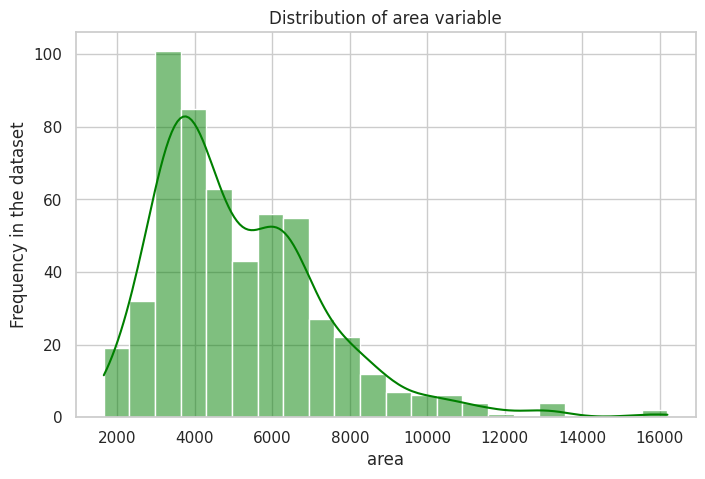

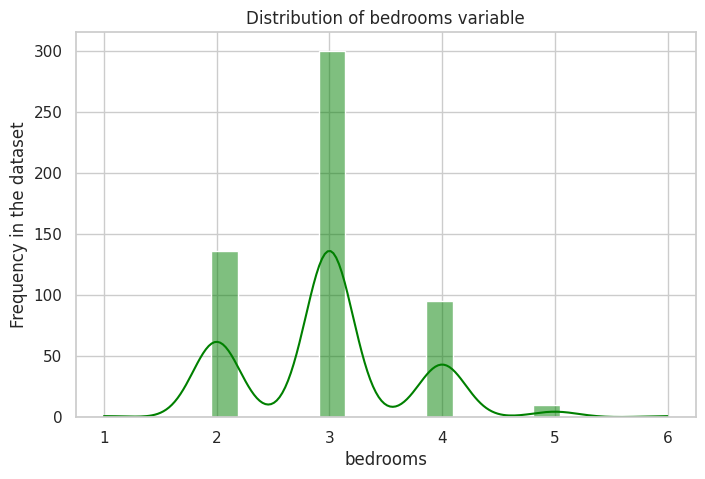

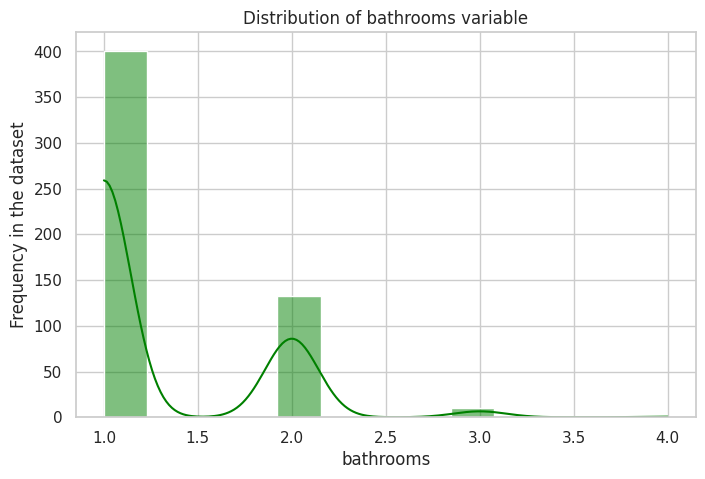

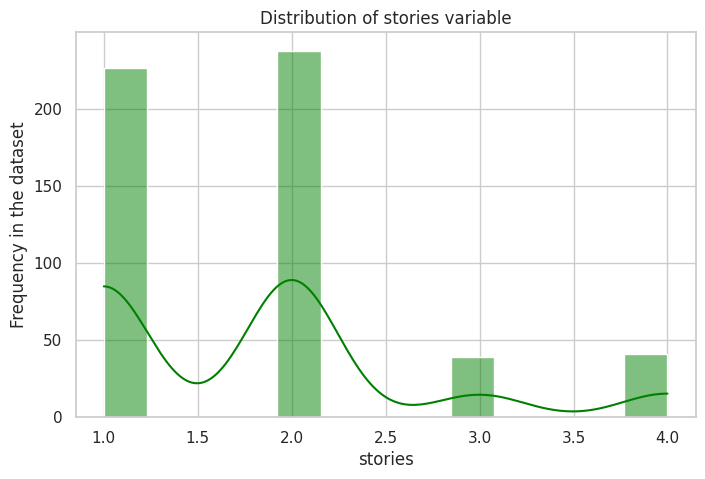

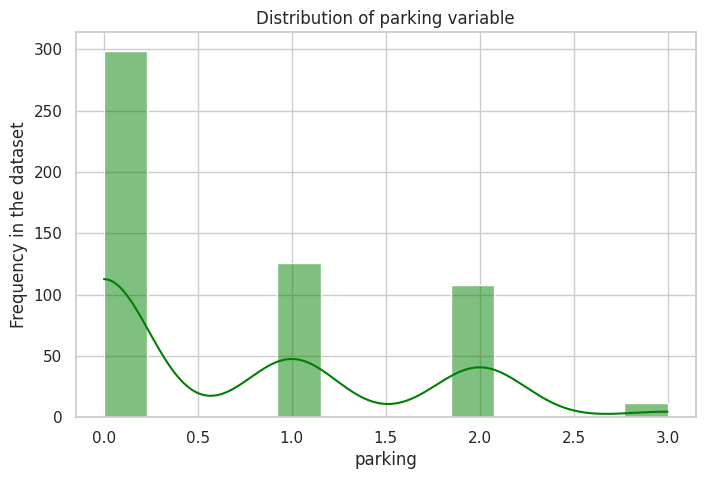

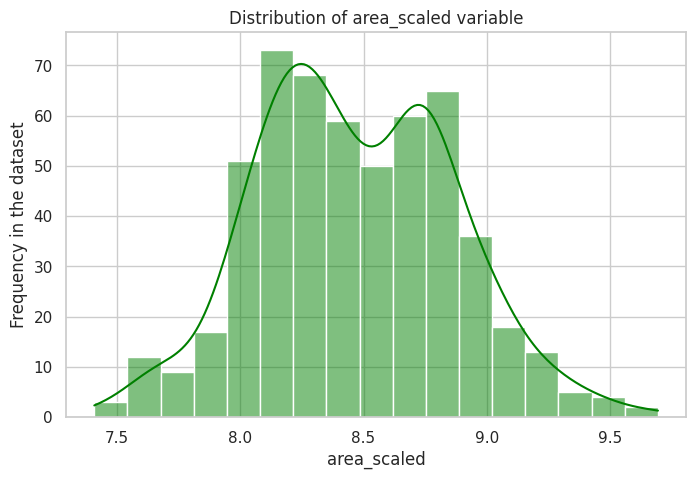

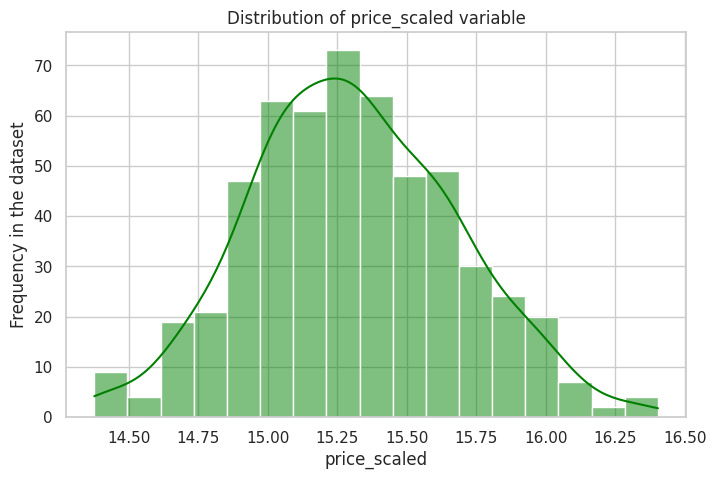

In [6]:
#Visualize the distribution of numerical variables
sns.set_theme(style = 'whitegrid')
for variable in X_numerical_columns:
  plt.figure(figsize = (8,5))
  sns.histplot(data= df, x = f'{variable}', color = 'green', kde = True)
  plt.xlabel(f'{variable}')
  plt.ylabel('Frequency in the dataset')
  plt.savefig(f'Distribution of {variable}.png')
  plt.title(f'Distribution of {variable} variable')
  plt.show()


# Categorical features distribution

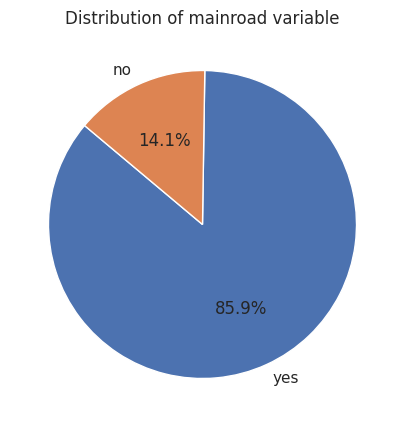

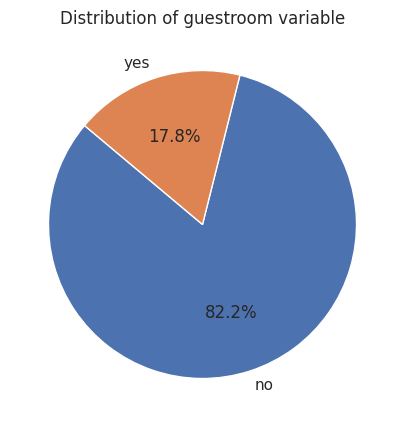

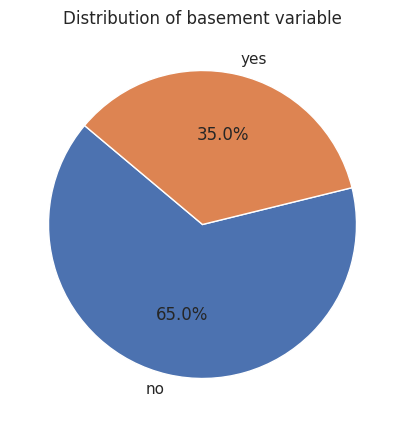

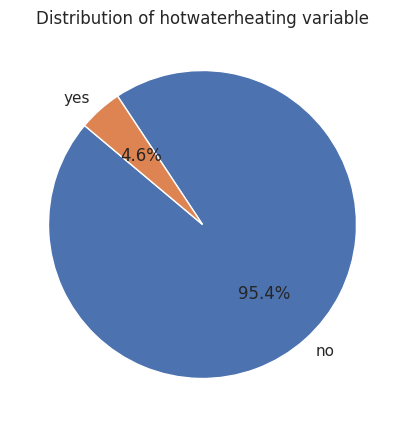

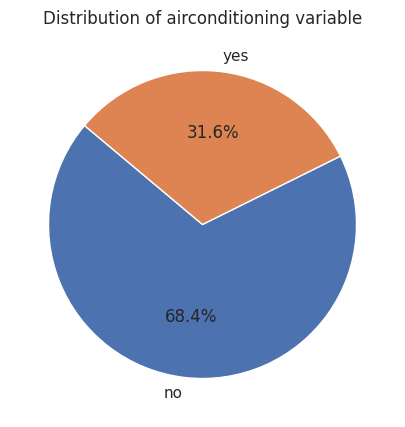

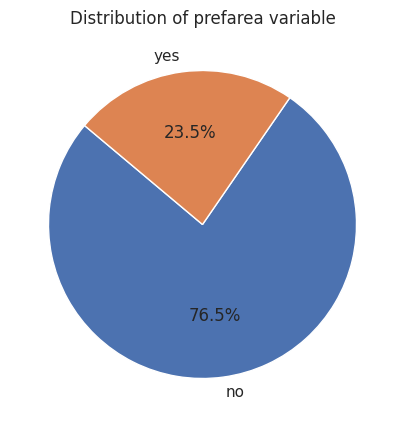

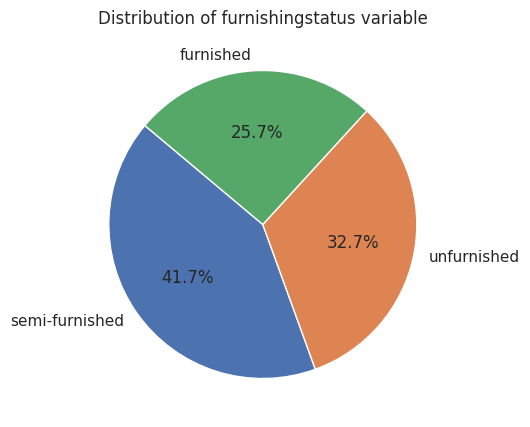

In [7]:
for variable in X_categorical_columns:
  counts = X[variable].value_counts()
  plt.figure(figsize=(8,5))
  plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
  plt.savefig(f'Distribution of  categorical {variable}.png')
  plt.title(f'Distribution of {variable} variable')
  plt.show()

# Outlier exploration for Numerical features

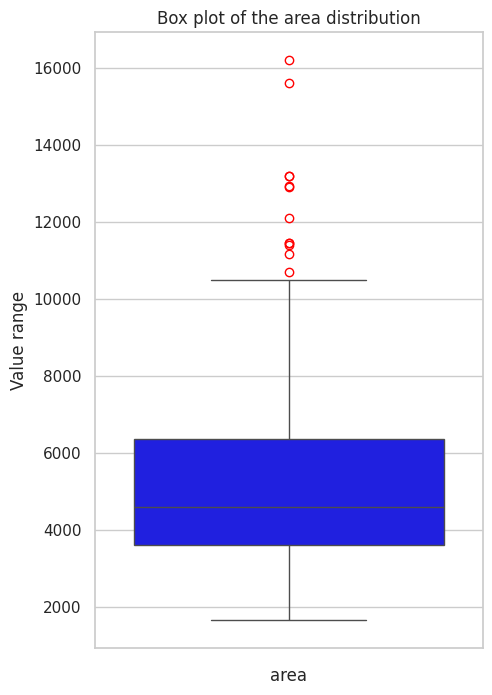

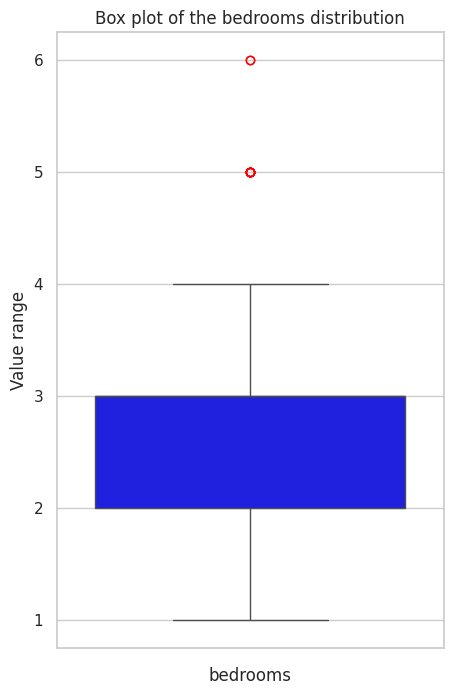

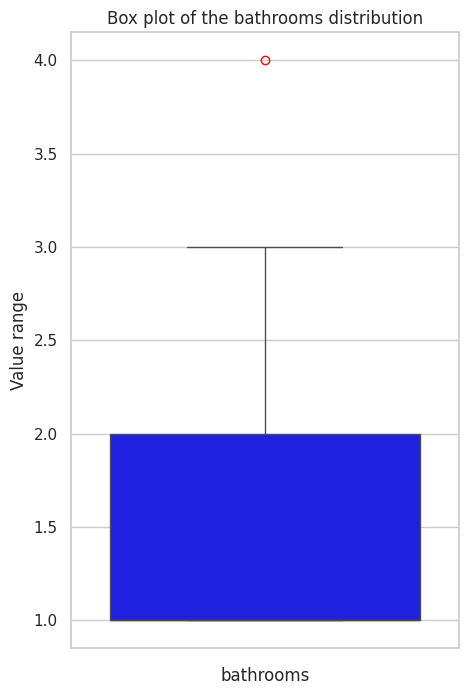

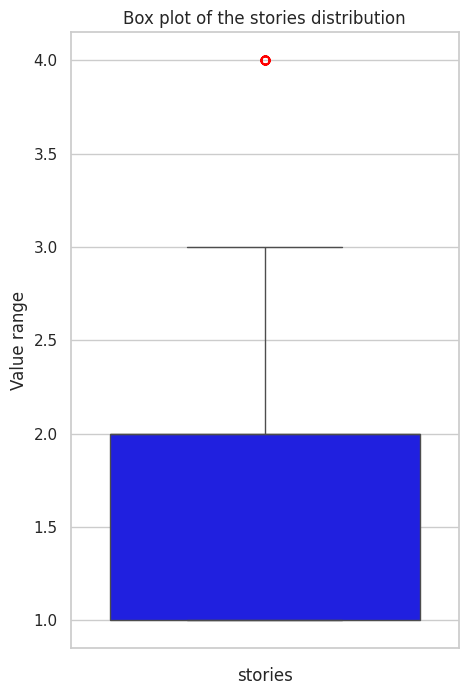

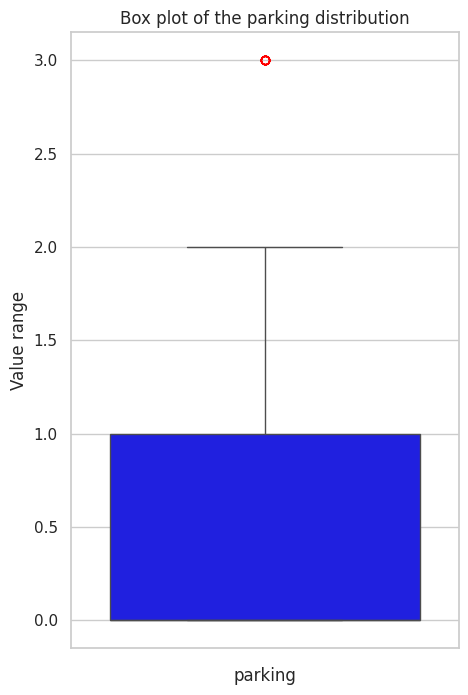

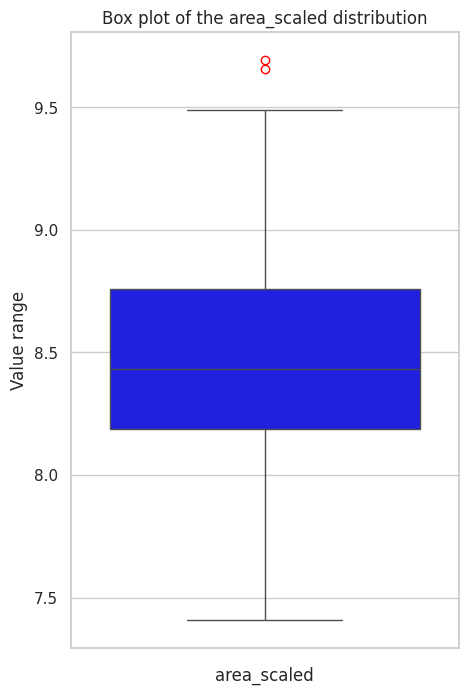

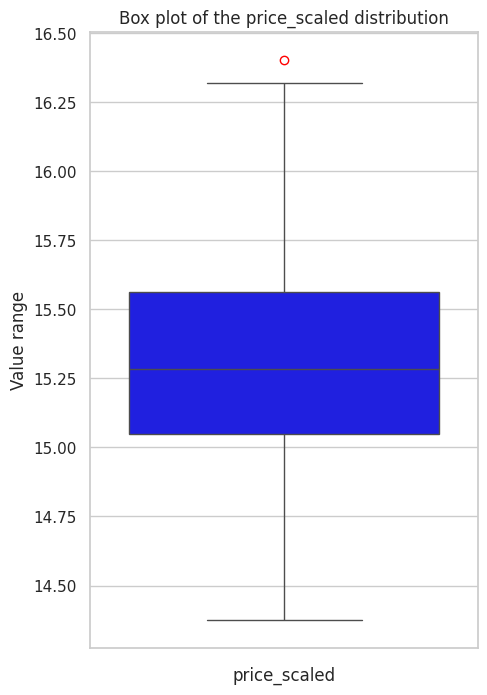

In [8]:

for variable in X_numerical_columns:
  plt.figure(figsize=(5,8))
  sns.boxplot(df[variable], color = 'blue', flierprops={"marker": "o", "markeredgecolor": "red"})
  plt.xlabel(f'{variable}')
  plt.ylabel('Value range')
  plt.savefig(f'Box plot of the {variable} distribution.png')
  plt.title(f'Box plot of the {variable} distribution')
  plt.show()

# Outlier exploration for Categorical Variables


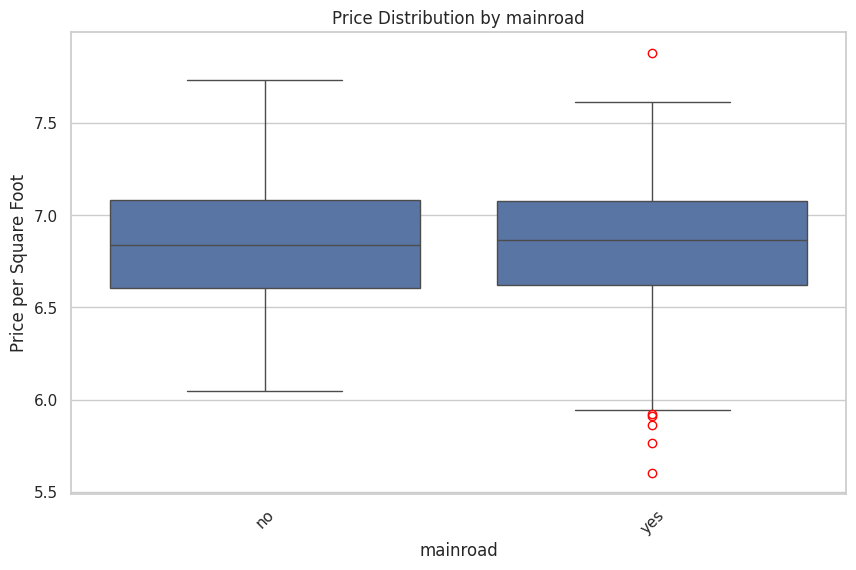

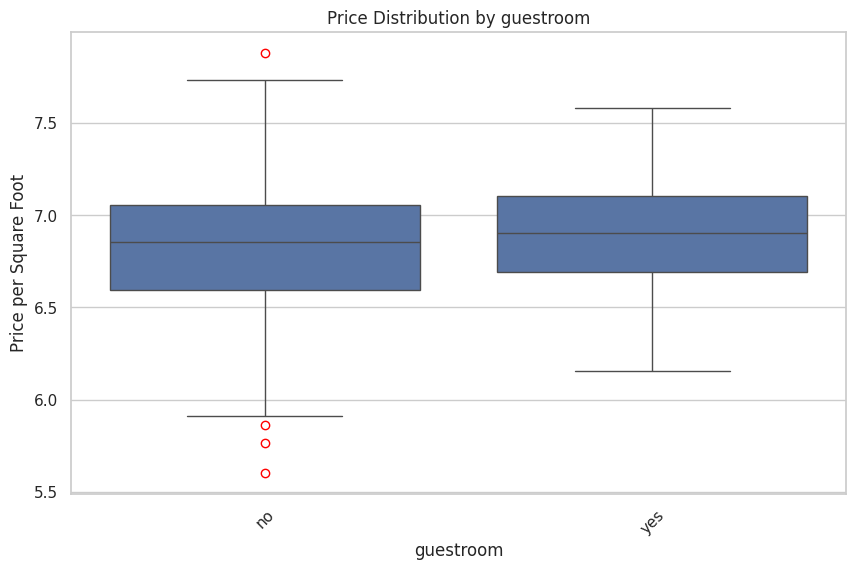

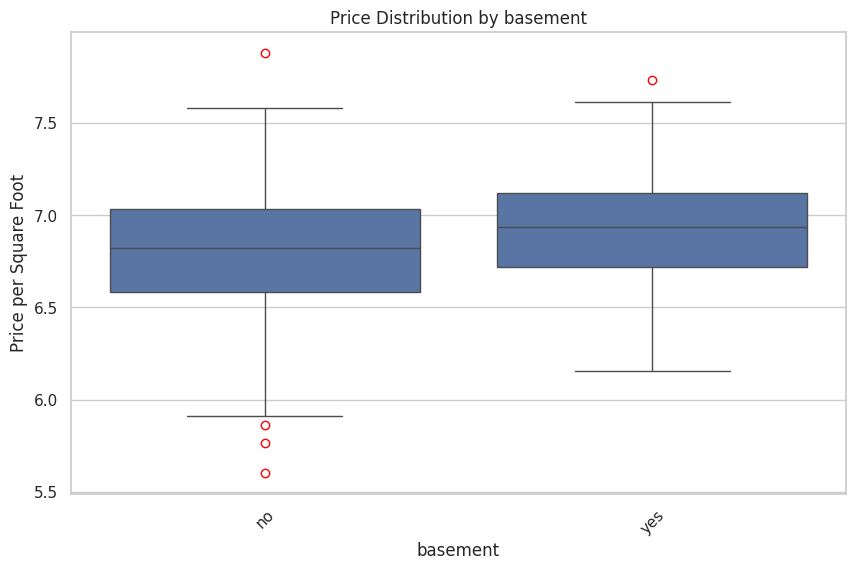

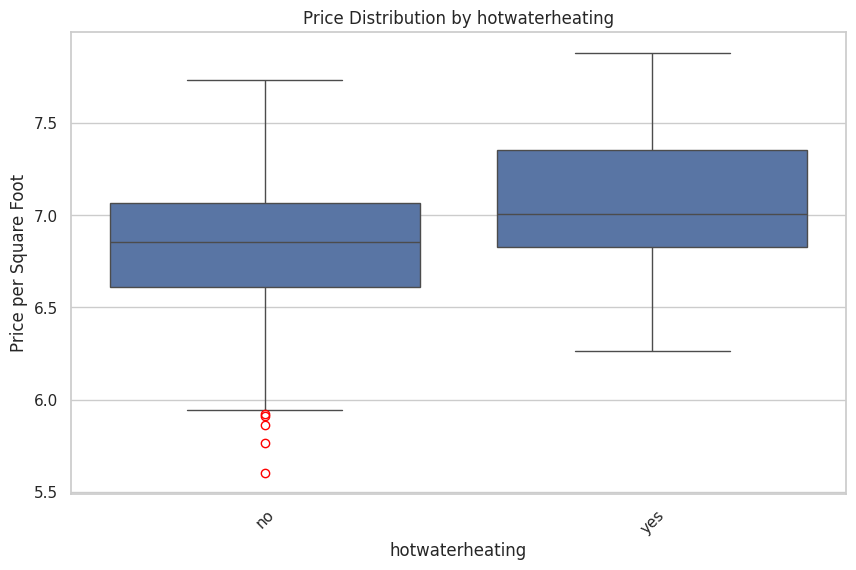

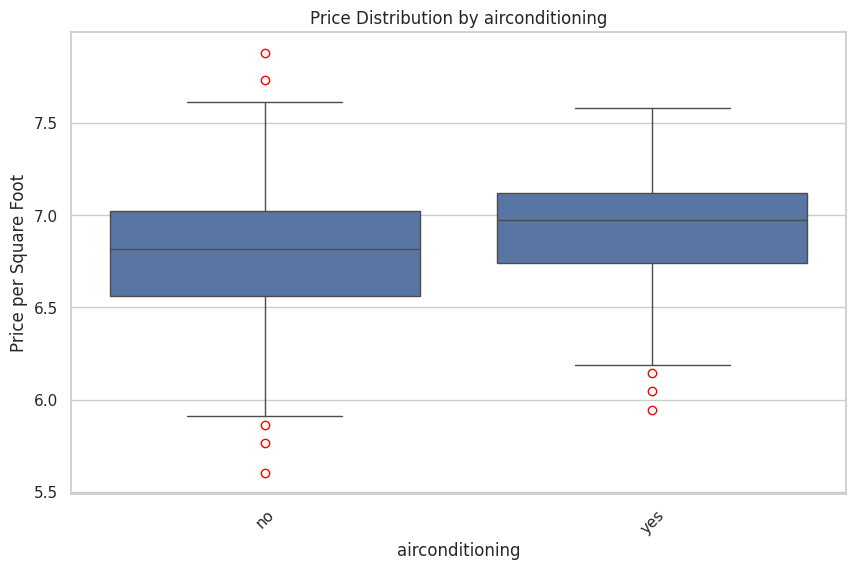

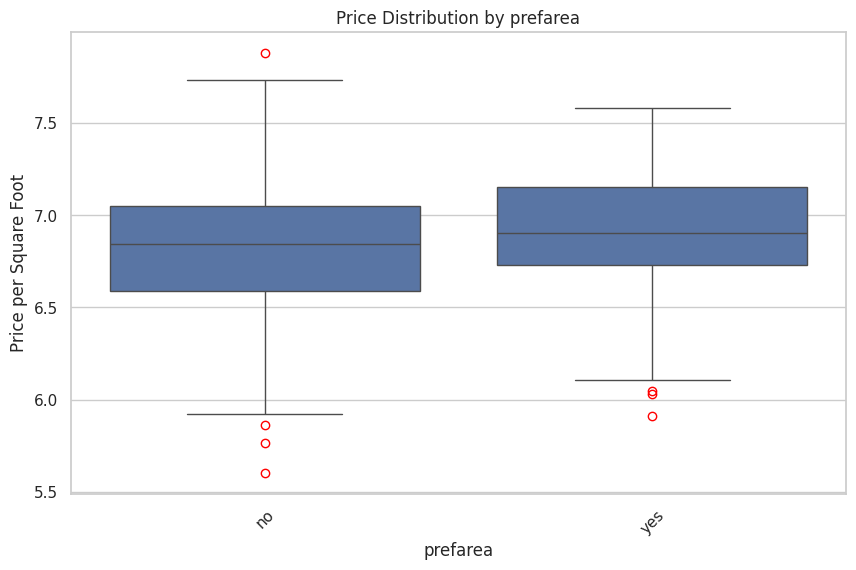

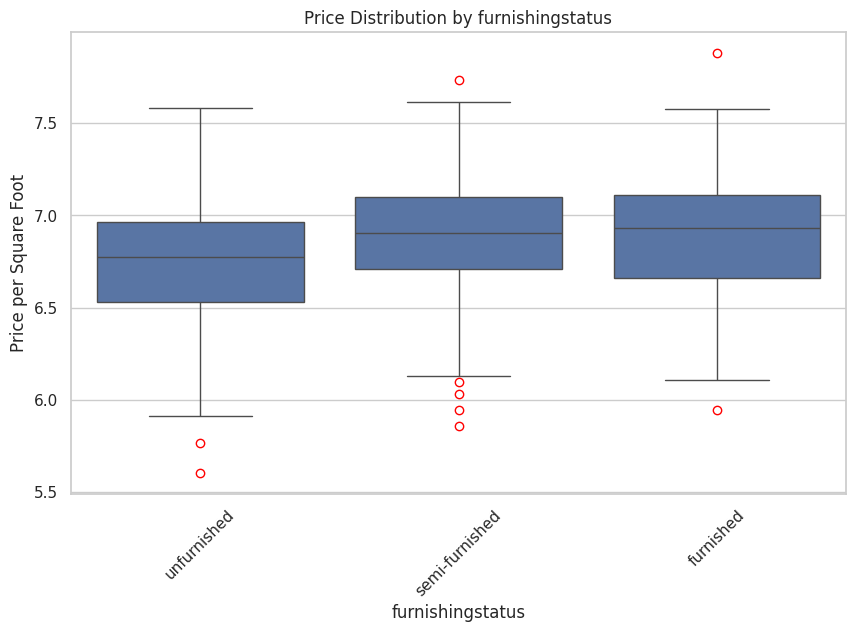

In [9]:
#Create the price per square column to detect categorical outliers more efficiently.
df['price_per_sqft'] = df['price']/df['area']
#Create the scaled price per sqft
df['price_per_sqft_scaled'] = np.log1p(df['price_per_sqft'])

for cat in X_categorical_columns:
    plt.figure(figsize=(10, 6))
    my_order = df.groupby(cat)['price_per_sqft_scaled'].median().sort_values().index
    sns.boxplot(data=df, x=cat, y='price_per_sqft_scaled', order=my_order, flierprops = {'marker': 'o', 'markeredgecolor':'red'})
    plt.title(f'Price Distribution by {cat}')
    plt.xlabel(cat)
    plt.ylabel('Price per Square Foot')
    plt.savefig(f'Box plot of the categorical {cat} distribution.png')
    plt.xticks(rotation=45)
    plt.show()

# Numerical and Categorical Variables Insights
Based on the previous analysis, we concluded the following:

* Continuous Variables (Area & Price per SqFt): We identified statistical outliers in the area and price_per_sqft distributions. These specific anomalies were removed using the IQR method as they represented significant noise (e.g., impossible price-to-size ratios). This cleaning process resulted in a data loss of only 3.3% (18 rows), which improves model stability without sacrificing significant information.

* Discrete/Categorical Variables (Bedrooms, Stories, etc.): We decided not to apply outlier removal to discrete variables such as bedrooms, bathrooms, or stories. Analysis showed that high values in these columns (e.g., 4 stories, 6 bedrooms) represent valid luxury properties rather than data errors. Retaining these "outliers" is crucial for the model to accurately learn the valuation of high-end real estate.

# Numerical Variable correlation

# Pearson's correlation matrix

In [ ]:
#Calculate correlation matrix
X_correlation_matrix  = df[X_numerical_columns.to_list()+[target]].corr(method = 'pearson')
# Print correlation matrix
print(f'The correlation matrix associated to X is : {X_correlation_matrix}')
#Extract from the correlation matrix just the wanted information about price variable
X_price_correlation = X_correlation_matrix[target]
#Ordering the values in the vector of price correlation
X_price_correlation = X_price_correlation.sort_values(ascending = False)
#Print the ordered correlation vector
print(f'The correlation vector is: \n {X_price_correlation}')

The correlation matrix associated to X is :                   area  bedrooms  bathrooms   stories   parking  area_scaled  \
area          1.000000  0.151858   0.193820  0.083996  0.352980     0.964342   
bedrooms      0.151858  1.000000   0.373930  0.408564  0.139270     0.150463   
bathrooms     0.193820  0.373930   1.000000  0.326165  0.177496     0.202612   
stories       0.083996  0.408564   0.326165  1.000000  0.045547     0.108145   
parking       0.352980  0.139270   0.177496  0.045547  1.000000     0.360776   
area_scaled   0.964342  0.150463   0.202612  0.108145  0.360776     1.000000   
price_scaled  0.543233  0.369986   0.485715  0.415281  0.371638     0.580085   
price         0.535997  0.366494   0.517545  0.420712  0.384394     0.561233   

              price_scaled     price  
area              0.543233  0.535997  
bedrooms          0.369986  0.366494  
bathrooms         0.485715  0.517545  
stories           0.415281  0.420712  
parking           0.371638  0.384394  
a

# Mutual Information Correlation


In [ ]:

#Calculate Mutual information correlation with respect to price variable
mi_scores = mutual_info_regression(df[X_numerical_columns], y)
#Creating a more understandable dataframe about correlations with price variable
mi_scores = pd.Series(mi_scores, name="MI Scores", index=df[X_numerical_columns].columns)
#Sort the variables correlation values
mi_scores = mi_scores.sort_values(ascending=False)
#Print the correlation values
mi_scores

,MI Scores
price_scaled,4.423259
area,0.281316
area_scaled,0.271823
parking,0.127037
stories,0.124372
bathrooms,0.121031
bedrooms,0.110225


# Data preprocessing

# Outlier deletion

In [ ]:

def outlier_deletion(df, column,threshold):
  q1 = df[column].quantile(0.25)
  q3 = df[column].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - threshold * iqr
  upper_bound = q3 + threshold * iqr
  df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
  return df

#Update our dataset

In [ ]:
df_without_area_outliers = outlier_deletion(df, 'area', 1.5)
df_without_price_outliers = outlier_deletion(df_without_area_outliers, 'price_per_sqft_scaled', 1.5)
df_cleaned = df_without_price_outliers



#Verify that deleted data were less than 5%



In [ ]:
original_data_amount = len(df)
number_of_data_loss  =original_data_amount -  len(df_cleaned)
data_loss_percentage = (number_of_data_loss/original_data_amount)*100
print(f'The data loss percentage after outlier deletion is : {data_loss_percentage:.2f}%')

The data loss percentage after outlier deletion is : 3.30%


#Update training and target instances

In [ ]:
#Update our target and training instances
y = df_cleaned['price_scaled']
X = df_cleaned
#Delate X columns that might contribute to data leakage
X = X.drop(['price_scaled', 'price_per_sqft_scaled','area','price_per_sqft','price'], axis=1)



In [ ]:
X

,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_scaled
0,4,2,3,yes,no,no,no,yes,2,yes,furnished,8.912069
1,4,4,4,yes,no,no,no,yes,3,no,furnished,9.100637
2,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,9.206433
3,4,2,2,yes,no,yes,no,yes,3,yes,furnished,8.922792
4,4,1,2,yes,yes,yes,no,yes,2,no,furnished,8.912069
...,...,...,...,...,...,...,...,...,...,...,...,...
540,2,1,1,yes,no,yes,no,no,2,no,unfurnished,8.006701
541,3,1,1,no,no,no,no,no,0,no,semi-furnished,7.783641
542,2,1,1,yes,no,no,no,no,0,no,unfurnished,8.194506
543,3,1,1,no,no,no,no,no,0,no,furnished,7.976252


# Preprocessing pipeline

# Numerical Pipeline

In [ ]:
polynomial_degree = 2
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly_features', PolynomialFeatures(degree=polynomial_degree,include_bias = False)),
    ('std_scaler', StandardScaler())
])

# Categorical pipeline

In [ ]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encoder', OneHotEncoder())
])

# Full pipeline

In [ ]:

#Update the categorical and numerical columns according to our data cleaning
X_numerical_columns = X.select_dtypes(include=['int64']).columns
X_categorical_columns = X.select_dtypes(include=['object']).columns

# 1. Create the Preprocessor (only for data transformation)
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, X_numerical_columns),
    ('categorical', categorical_pipeline, X_categorical_columns)
])

# 2. Create the Full Pipeline (Preprocessor + Estimator)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(random_state=42))
])


# Split the dataset into training and test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Establish a  model parameter gird

In [ ]:
param_grid = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1],
    'model__penalty': ['l1', 'l2', 'elasticnet'], # Fixed string
    'model__max_iter': [1000, 5000],
    'model__tol': [1e-3, 1e-4],
    'model__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'model__eta0': [0.01, 0.001], # Initial learning rate
    'model__l1_ratio': [0.15, 0.5, 0.8] # Only used for elasticnet
}

# Runing search of model parameters

In [ ]:
gird_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs =-1)
gird_search.fit(X_train, y_train)
gird_search.best_params_


{'model__alpha': 0.001,
 'model__eta0': 0.01,
 'model__l1_ratio': 0.15,
 'model__learning_rate': 'constant',
 'model__max_iter': 1000,
 'model__penalty': 'l1',
 'model__tol': 0.0001}

# Setting best model

In [ ]:
model = gird_search.best_estimator_
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs= -1)
scores
r_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs = -1)
r_scores
print(f'The model rmse is {np.mean(-scores)}')
print(f'The model r2 is {np.mean(r_scores)}')

The model rmse is 0.21457333275727103
The model r2 is 0.6121643061017815


#Comparison of polynomial model with dummy model



# Construction of the dummy model

In [ ]:
from multiprocessing import Value
from sklearn.base import BaseEstimator, RegressorMixin

class DummyEstimator(BaseEstimator, RegressorMixin):
  """ A manual implementation od a Dummy Regressor.
  Predicts the mean or Mean  of the training target for all future imputs.
  """
  def __init__(self,strategy = 'mean'):
    self.strategy = strategy
    self.reference_value = None

  def fit(self, X, y):
    if self.strategy == 'mean':
      self.reference_value = np.mean(y)
    elif self.strategy == 'median':
      self.reference_value = np.median(y)
    else :
      ValueError('Unknown strategy: Strategy must be mean or median')
    return self

  def predict(self, X):
    if self.reference_value is None:
      raise ValueError('Model not fitted yet')

    return np.full(X.shape[0], self.reference_value)


# Calculate prediction of the dummy model in test set

In [ ]:
dummy_model = DummyEstimator()
dummy_model.fit(X_train, y_train)
dummy_test_predictions = dummy_model.predict(X_test)


# Comparison of polynomial model performance vs dummy model in training data



In [ ]:
y_polinomial_scores = cross_val_score(model, X_train, y_train, cv = 5, n_jobs = -1, scoring = 'neg_root_mean_squared_error')
r_polynomial_scores = cross_val_score(model, X_train, y_train, cv= 5, n_jobs= -1, scoring = 'r2')
print(f'The model rmse is {np.mean(-y_polinomial_scores)}')
print(f'The model r2 is {np.mean(r_polynomial_scores)}')

y_dummy_scores = cross_val_score(dummy_model, X_train, y_train, cv = 5, n_jobs= -1, scoring= 'neg_root_mean_squared_error')
r_dummy_scores = cross_val_score(dummy_model, X_train, y_train, cv = 5, n_jobs= -1, scoring = 'r2')

print(f'The dummy model rmse is {np.mean(-y_dummy_scores)}')
print(f'The dummy model r2 is {np.mean(r_dummy_scores)}')

The model rmse is 0.21457333275727103
The model r2 is 0.6121643061017815
The dummy model rmse is 0.3457827058714571
The dummy model r2 is -0.00570050907864621


# Model comparison veredict

The Polynomial model outperformed the Dummy model across all metrics, proving that the features and polynomial transformations are capturing real patterns in the real estate market.

* The Baseline Failure: The Dummy model's $R^2$ of effectively 0.0 confirms that simply using the average price of the dataset is insufficient for valuing properties. The high RMSE (0.346) indicates that the market has too much variance for a "one-size-fits-all" price to be useful.
 * The Polynomial Success: The model achieved an $R^2$ of 0.61, meaning it explains nearly two-thirds of the factors that drive price differences (such as area, stories, and bathroom count).Error Reduction: By reducing the RMSE from 0.346 to 0.215, the Polynomial model tightens the prediction window significantly. In practical terms, where the Dummy model might misprice a house by ~35%, the Polynomial model narrows that average error to ~21%.

# Model learning analysis

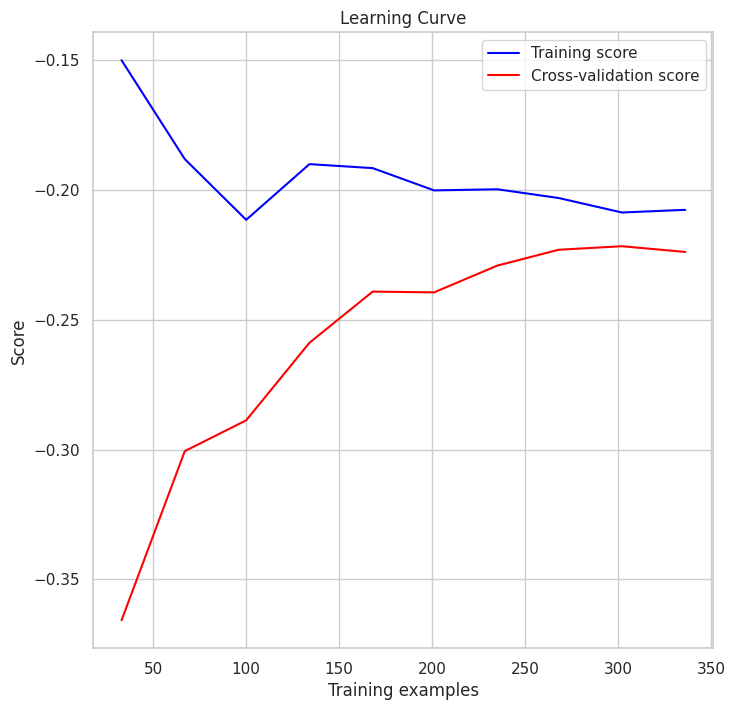

In [ ]:
from sklearn.model_selection import learning_curve
def plot_learning_curve(estimator, X,y):
  train_sizes, train_scores,test_scores = learning_curve(estimator, X,y,cv = 5,n_jobs =-1,train_sizes = np.linspace(0.1,1,10),scoring = 'neg_root_mean_squared_error')

  train_mean = np.mean(train_scores, axis = 1)
  test_mean = np.mean(test_scores, axis = 1)
  train_std = np.std(train_scores, axis = 1)
  test_std = np.std(test_scores, axis = 1)

  plt.figure(figsize=(8,8))
  plt.plot(train_sizes, train_mean, label = 'Training score', color = 'blue')
  plt.plot(train_sizes, test_mean, label = 'Cross-validation score', color = 'red')

  plt.title('Learning Curve')
  plt.xlabel('Training examples')
  plt.ylabel('Score')
  plt.legend()
  plt.show()
plot_learning_curve(model, X_train, y_train)

# Model performance in test set


In [ ]:

y_test_pred = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"Final Test RMSE: {test_rmse}")
print(f"Final Test R2: {test_r2}")


Final Test RMSE: 0.278466698822119
Final Test R2: 0.5947397524761723


# Residual Analysis

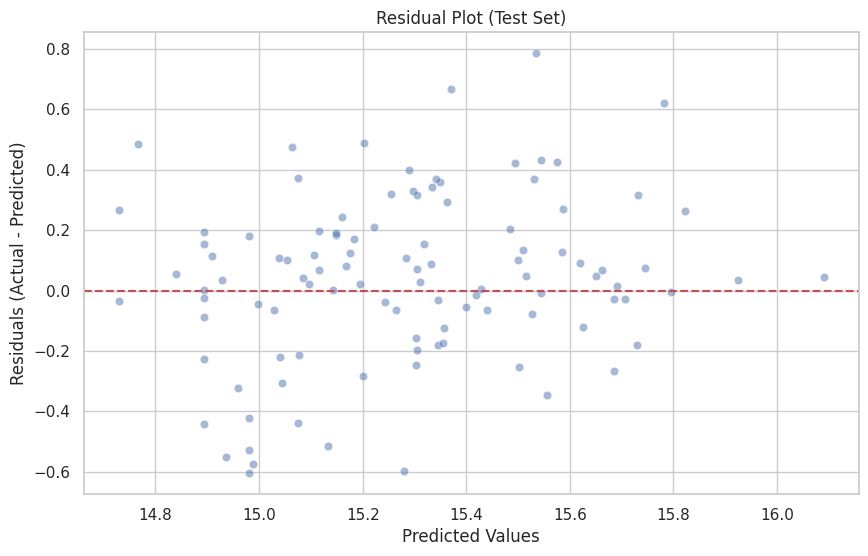

In [ ]:


residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Test Set)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Areas of improvement of the model based on residual analysis

# Residual Analysis SummaryVerdict:

 * Statistically Valid & Healthy.The residual plot displays a random distribution of errors centered around zero, confirming that the model fits the data well without systemic bias
 * Homoscedasticity Confirmed: The vertical spread of errors is consistent across the entire price range (from cheap to expensive properties). This validates that the Log Transformation successfully stabilized the variance, preventing the model from becoming unreliable on luxury homes.
 * No Non-Linearity Detected: The absence of a "U-shape" or curve pattern indicates that the Polynomial features successfully captured the complex relationships in the data. The model is not underfitting.

 * Outlier Insight: A few isolated points show high residuals (prediction errors > ±0.6). These represent properties with unobserved characteristics (e.g., condition, renovations) rather than model failure.

 * Conclusion: The model adheres to the core assumptions of regression and provides reliable error estimates ($\sim$32%) across the entire dataset.